# Exploratory Data Analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data

In [ ]:
data_folder = '../data/'

# load the training data (2022-2024)
df_2022 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2022.parquet'))
df_2023 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2023.parquet'))
df_2024 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2024.parquet'))

# merge into one big training dataset
train_df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

# filter dataset to only include 'run' and 'pass' plays
valid_plays = ['run', 'pass']
train_df = train_df[train_df['play_type'].isin(valid_plays)].copy()

## EDA

In [9]:
# Make sure we're above the 50,000 play threshold for the rubric
print(f"Valid plays in training set: {len(train_df)}")
print(f"Number of columns: {len(train_df.columns)}")

Valid plays in training set: 106080
Number of columns: 372


In [13]:
# filter columns to only include those that are relevant for modeling
features_to_keep = [
    'play_type', 'down', 'ydstogo', 'yardline_100', 
    'score_differential', 'qtr', 'half_seconds_remaining'
]
clean_train_df = train_df[features_to_keep].copy()
clean_train_df.head()

,play_type,down,ydstogo,yardline_100,score_differential,qtr,half_seconds_remaining
2,run,1.0,10.0,78.0,0.0,1.0,1796.0
3,pass,1.0,10.0,59.0,0.0,1.0,1769.0
4,run,2.0,10.0,59.0,0.0,1.0,1765.0
5,pass,3.0,5.0,54.0,0.0,1.0,1741.0
7,pass,1.0,10.0,72.0,0.0,1.0,1722.0


In [14]:
# Missing values per columns
missing_values = clean_train_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
play_type                   0
down                      399
ydstogo                     0
yardline_100                0
score_differential          0
qtr                         0
half_seconds_remaining      0
dtype: int64


## Baseline

Overall Play Call Tendencies:
play_type
pass    57.618778
run     42.381222
Name: proportion, dtype: float64


/var/folders/gk/9lkdwrfd0hbd5gv7phvzxn440000gn/T/ipykernel_80884/2063437540.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='play_type', palette='Set2')


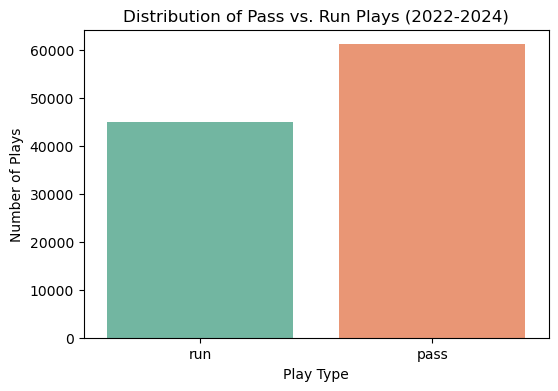

In [15]:
# calculate run vs pass ratio
target_dist = train_df['play_type'].value_counts(normalize=True) * 100

print("Overall Play Call Tendencies:")
print(target_dist)

# VISUAL 1: A simple bar chart of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='play_type', palette='Set2')
plt.title('Distribution of Pass vs. Run Plays (2022-2024)')
plt.ylabel('Number of Plays')
plt.xlabel('Play Type')
plt.show()